In [1]:
from pathlib import Path
import scanpy as sc
from cytetype import CyteType, rank_genes_groups_backed

In [2]:
# grabbed from ../study_context/contexts_inspection.ipynb
study_context = "Tissue: Whole Lung Dissociate. Library strategy: RNA-Seq. Library prep: Thawed Cells were rinsed with 10% FBS passed through 40 uM strainer 10X Genomics 3 prime v2. Description: Single Cell RNAseq of Whole Lung Dissociates from IPF, COPD and control lungs Overall design: Exploratory analysis of disease and healthy lung cell populations. Abstract: Airway mucociliary regeneration and function are key players for airway defense and are impaired in chronic obstructive pulmonary disease (COPD). Using transcriptome analysis in COPD-derived bronchial biopsies, we observed a positive correlation between cilia-related genes and microRNA-449 (miR449). In vitro, miR449 was strongly increased during airway epithelial mucociliary differentiation. In vivo, miR449 was upregulated during recovery from chemical or infective insults. miR0449-/- mice (both alleles are deleted) showed impaired ciliated epithelial regeneration after naphthalene and Haemophilus influenzae exposure, accompanied by more intense inflammation and emphysematous manifestations of COPD. The latter occurred spontaneously in aged miR449-/- mice. We identified Aurora kinase A and its effector target HDAC6 as key mediators in miR449-regulated ciliary homeostasis and epithelial regeneration. Aurora kinase A is downregulated upon miR449 overexpression in vitro and upregulated in miR449-/- mouse lungs. Accordingly, imaging studies showed profoundly altered cilia length and morphology accompanied by reduced mucociliary clearance. Pharmacological inhibition of HDAC6 rescued cilia length and coverage in miR449-/- cells, consistent with its tubulin-deacetylating function. Altogether, our study establishes a link between miR449, ciliary dysfunction, and COPD pathogenesis."
adata = sc.read_h5ad(Path("../data/other/final_adata_SRX17412841.h5ad"), backed="r")
group_key = "leiden_merged"

In [3]:
rank_genes_groups_backed(
    adata,
    groupby=group_key,
    use_raw=False,
    key_added='rank_genes_' + group_key
)

rank_genes_groups_backed: 100%|██████████| 1/1 [00:00<00:00, 10.08chunk/s]

Computing t-test statistics for 17 groups...


rank_genes_groups_backed complete — 24280 genes per group written to adata.uns['rank_genes_leiden_merged']


In [4]:
annotator = CyteType(
    adata,
    group_key,
    rank_key="rank_genes_" + group_key,
    n_top_genes=100
)

Auto-detected gene symbols in column 'gene_symbols' (0% ID-like, 100% unique).
Using coordinates from 'X_umap' for visualization.
Materialized canonical gene symbols in temporary column '__cytetype_gene_symbols' from column 'gene_symbols'.


Calculating expression percentages: 100%|██████████| 1/1 [00:00<00:00, 21.75chunk/s]

Extracting marker genes...
Aggregating cluster metadata...



Writing raw counts to H5 artifact: 100%|██████████| 3/3 [00:00<00:00, 23.17batch/s]


Writing obs data to duckdb artifact...
Data preparation completed. Ready for submitting jobs.


In [6]:
adata = annotator.run(study_context=study_context)

Uploading vars.h5 artifact...


Uploading: 100%|██████████| 2/2 [00:22<00:00, 11.48s/chunk]



Uploading obs.duckdb artifact...


Uploading: 100%|██████████| 1/1 [00:00<00:00,  1.68chunk/s]



CyteType job submitted.
If your session disconnects, results can still be fetched later with:
`results = annotator.get_results()`

[TRACK PROGRESS]
https://cytetype.nygen.io/report/db0b3596-a918-4b16-af8a-e2e32d04ad5e


✓ Job db0b3596-a918-4b16-af8a-e2e32d04ad5e completed successfully.
✓ Job db0b3596-a918-4b16-af8a-e2e32d04ad5e completed successfully.
✓ Job db0b3596-a918-4b16-af8a-e2e32d04ad5e completed successfully.
✓ Job db0b3596-a918-4b16-af8a-e2e32d04ad5e completed successfully.
     Annotation labels → adata.obs['cytetype_annotation_leiden_merged']
   Cell Ontology terms → adata.obs['cytetype_cellOntologyTerm_leiden_merged']
Cell Ontology term IDs → adata.obs['cytetype_ontologyTermID_leiden_merged']
           Cell states → adata.obs['cytetype_cellState_leiden_merged']
          Full results → adata.uns['cytetype_results']
Report:
https://cytetype.nygen.io/report/db0b3596-a918-4b16-af8a-e2e32d04ad5e


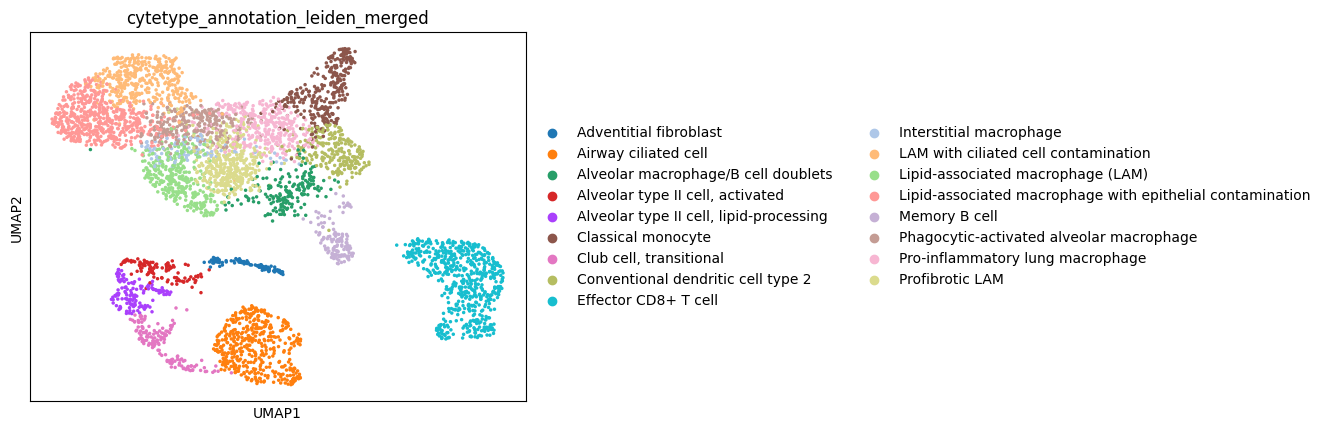

In [23]:
sc.pl.embedding(adata, basis='umap', color=f'cytetype_annotation_{group_key}')

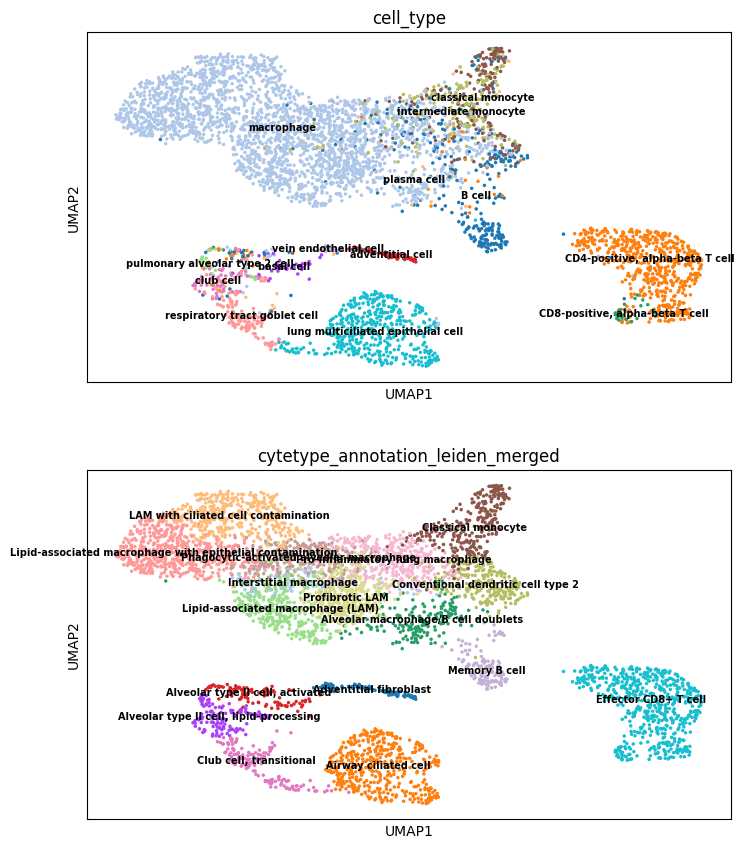

In [25]:
# Regenerate the UMAP plot with merged clusters and new title
fig = sc.pl.umap(
    adata,
    color=["cell_type", "cytetype_annotation_leiden_merged"],
    ncols=1,
    legend_loc="on data",
    legend_fontsize=7,
    wspace=0.4,
    show=False,
    return_fig=True,
)

In [7]:
import anndata

output_path = Path("..") / "data" / "other" / "SRX17412841_cytetype_annotated.h5ad"
adata.write_h5ad(output_path)